# __<u>Site Information: </u>__
> __Site # 02__
>>  - Location: **Gyeongju-si, Gyeongsangbuk-do**
>>  - Solar Plants: 9
>>>    - 9 Solar Plants (C_scode: **717800001 ~ 717800009**)

# __<u>Initialize Cloud-AI Engine</u>__ 
> Selected python version == 3.11
>> To access cmd: py -3.11 -m pip ....

> Install/Verify Packages

In [71]:
# %pip install --user --upgrade pandas
# %pip install --user --upgrade "sqlalchemy<2.0"
# %pip install --user --upgrade mariadb
# %pip install --user --upgrade -U matplotlib

> Import Libraries

In [72]:
import os
import sys
import pickle
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from datetime import time
import random

In [73]:
import sys, os
sys.path.append(os.path.abspath('..'))   # add the IGPS project root to the path

In [74]:
import importlib
import Library.dataProcessing
importlib.reload(Library.dataProcessing)

<module 'Library.dataProcessing' from 'f:\\RBM\\Educational\\UTS.au\\Research\\[P] KMU==IGPS in Solar Plants\\Firmware\\IGPS\\Library\\dataProcessing.py'>

# __<u>Configure Simulation Setup</u>__

>Define output directory

In [75]:
# Preprocessed data directory
preDataDirectory = '../../Database/2026-06-14/Preprocessed/'

# Root directory for the project
mainDirectory   = '../Export/'

# Define subdirectories for data, models, and figures
dataDirectory   = mainDirectory + 'Data/'
modelDirectory  = mainDirectory + 'Model/'
figDirectory    = mainDirectory + 'Figure/'

# create dataDirectory if it doesn't exist
if not os.path.exists(dataDirectory):
    os.makedirs(dataDirectory)
    print(f"System has created \"{dataDirectory}\" directory.")
else:
    print(f"The directory \"{dataDirectory}\" already exists.")

# create modelDirectory if it doesn't exist
if not os.path.exists(modelDirectory):
    os.makedirs(modelDirectory)
    print(f"System has created \"{modelDirectory}\" directory.")
else:
    print(f"The directory \"{modelDirectory}\" already exists.")


# create figDirectory if it doesn't exist
if not os.path.exists(figDirectory):
    os.makedirs(figDirectory)
    print(f"System has created \"{figDirectory}\" directory.")
else:
    print(f"The directory \"{figDirectory}\" already exists.")

The directory "../Export/Data/" already exists.
The directory "../Export/Model/" already exists.
The directory "../Export/Figure/" already exists.


> Define colunmns and rows of pandas output

In [76]:
import pandas as pd
pd.set_option('display.max_columns', 50)
pd.set_option('display.max_rows', 30)

# __<u>Data Processing for Model Development and Testing</u>__

In [77]:
PV1 = pd.read_csv(f"{preDataDirectory}PV_Plant_717800001.csv")
PV2 = pd.read_csv(f"{preDataDirectory}PV_Plant_717800002.csv")
PV3 = pd.read_csv(f"{preDataDirectory}PV_Plant_717800003.csv")
PV4 = pd.read_csv(f"{preDataDirectory}PV_Plant_717800004.csv")
PV5 = pd.read_csv(f"{preDataDirectory}PV_Plant_717800005.csv")
PV6 = pd.read_csv(f"{preDataDirectory}PV_Plant_717800006.csv")
PV7 = pd.read_csv(f"{preDataDirectory}PV_Plant_717800007.csv")
PV8 = pd.read_csv(f"{preDataDirectory}PV_Plant_717800008.csv")
PV9 = pd.read_csv(f"{preDataDirectory}PV_Plant_717800009.csv")
ENV = pd.read_csv(f"{preDataDirectory}Weather_Station_717804001.csv")

> Filter only effective data
>> Note:
>> We have considered Instantaneous Output Data of Each PV

In [78]:
rename_columns = {
    'DT': 'timestamp',
    'P_ac': 'P_pv',
    }
PV1.rename(columns=rename_columns, inplace=True)
PV2.rename(columns=rename_columns, inplace=True)
PV3.rename(columns=rename_columns, inplace=True)
PV4.rename(columns=rename_columns, inplace=True)
PV5.rename(columns=rename_columns, inplace=True)
PV6.rename(columns=rename_columns, inplace=True)
PV7.rename(columns=rename_columns, inplace=True)
PV8.rename(columns=rename_columns, inplace=True)
PV9.rename(columns=rename_columns, inplace=True)
ENV.rename(columns=rename_columns, inplace=True)

> Visualize Data

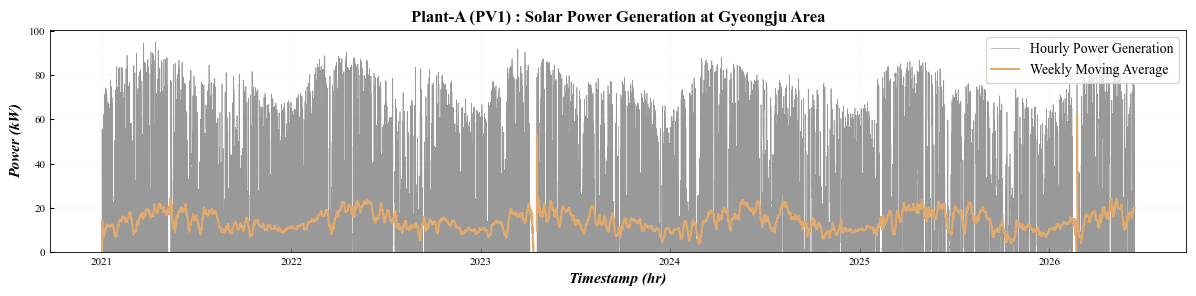

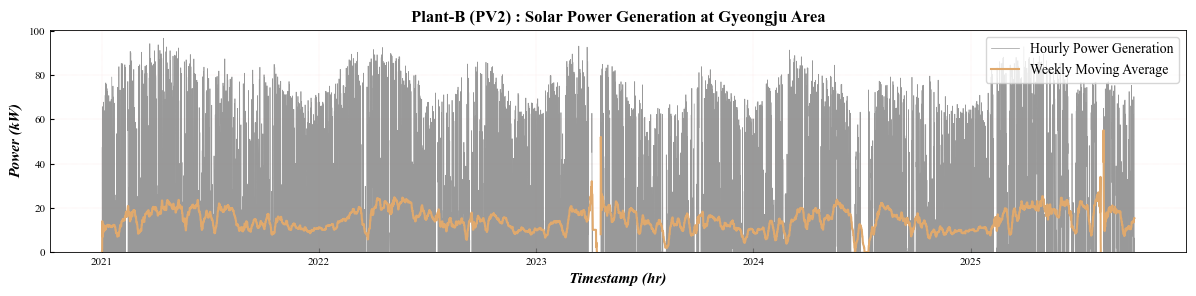

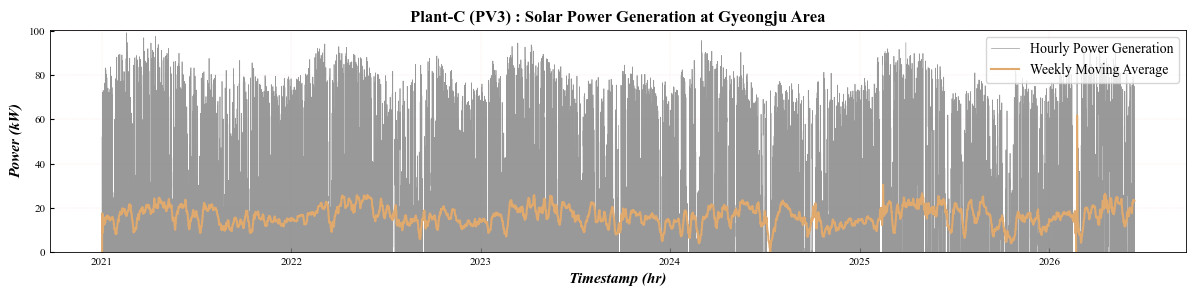

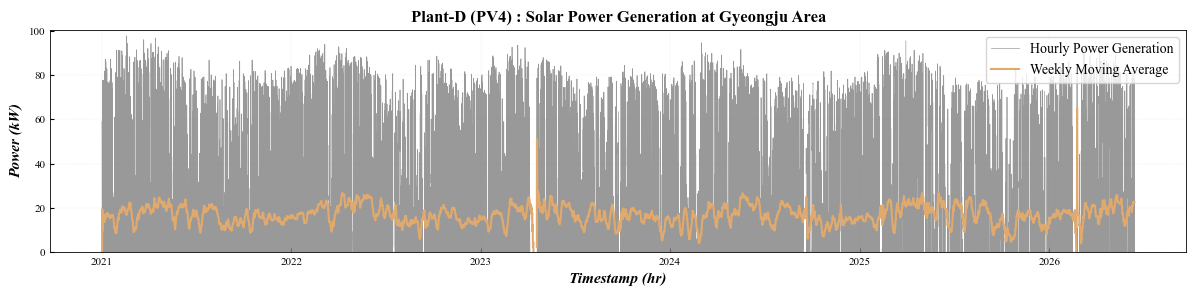

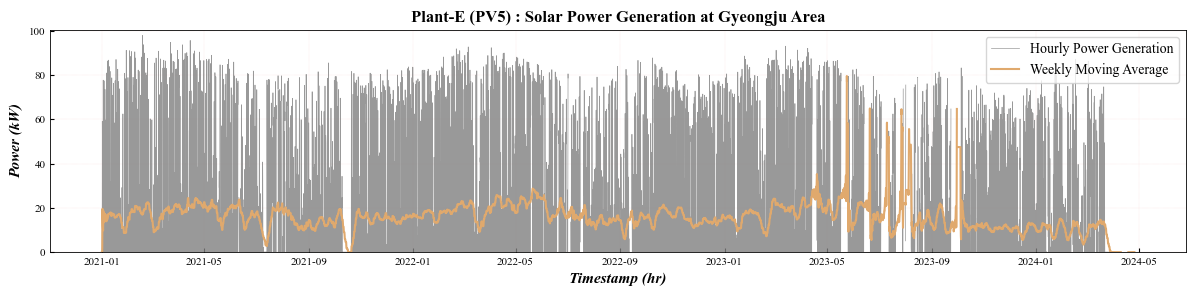

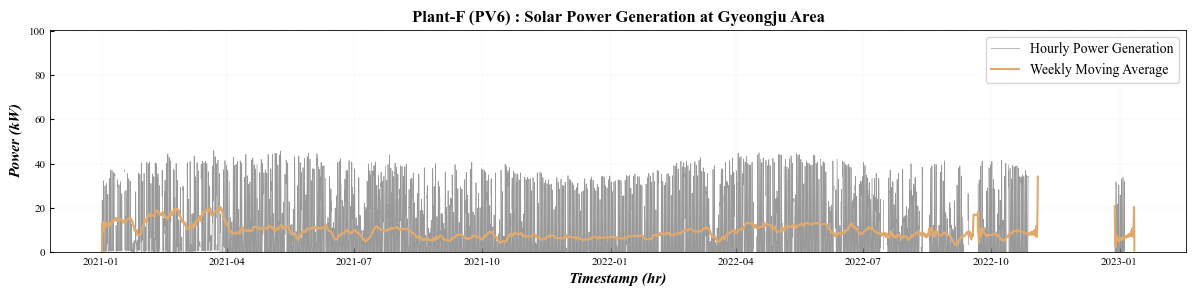

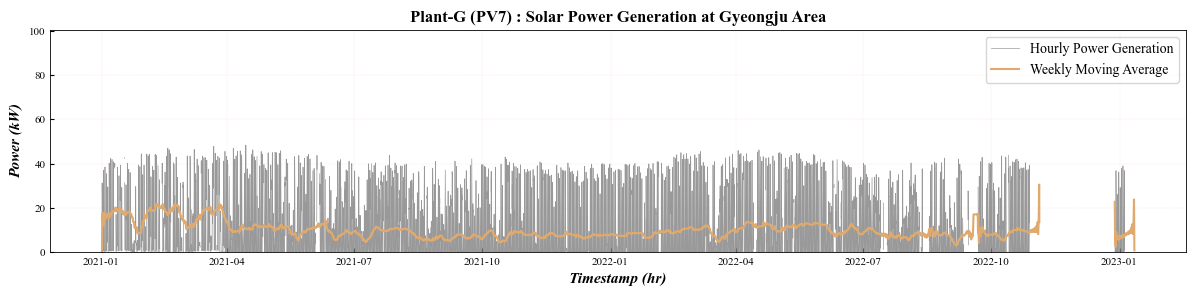

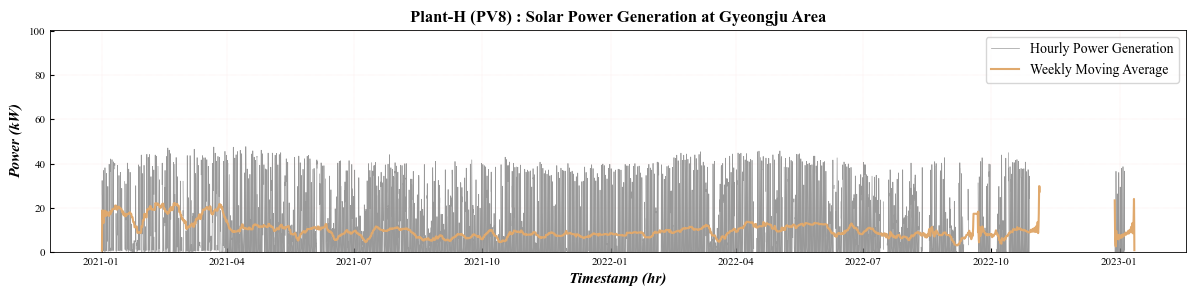

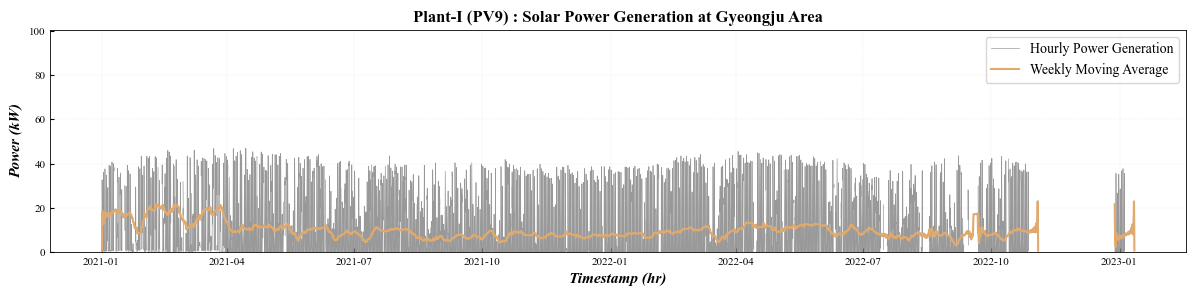

In [79]:
import string

from Library.dataProcessing import plot_pv_generation

for i in range(1, 10):
    pv = globals()[f"PV{i}"]                       # fetch PV1..PV9 by name
    plant_name = f"Plant-{string.ascii_uppercase[i-1]} (PV{i})"  # i=1 -> A
    plot_pv_generation(pv, PlantName=plant_name, AreaName='Gyeongju Area')

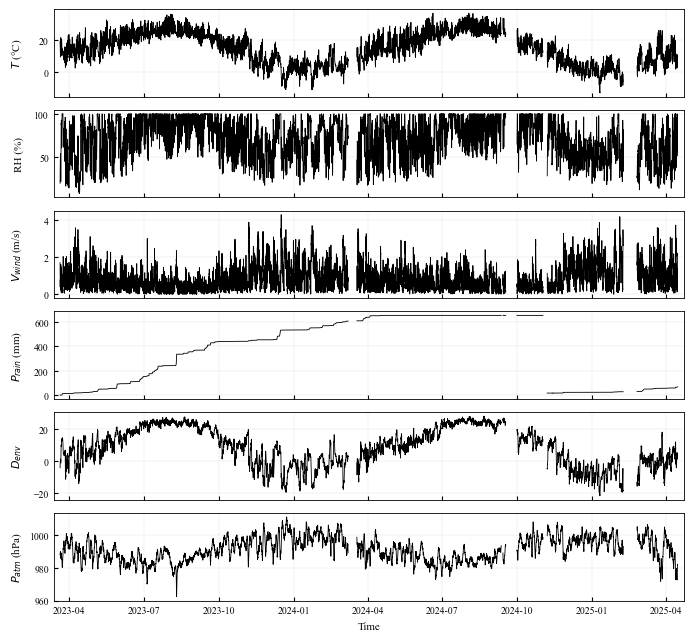

In [80]:
from Library.dataProcessing import plot_weather_data
plot_weather_data(ENV, x_col='timestamp', save_fig=False)

> Combine the most appropriate data into a dataframe

In [81]:
# Ensure datetime index for all three
for df in (PV1, PV3, PV4, ENV):
    df['timestamp'] = pd.to_datetime(df['timestamp'])

freq = 'h'   # common time grid — choose 'min', '10min', 'h', etc.

pv1_h = PV1.set_index('timestamp').resample(freq).mean().add_prefix('PV1_')
pv3_h = PV3.set_index('timestamp').resample(freq).mean().add_prefix('PV2_')
pv4_h = PV4.set_index('timestamp').resample(freq).mean().add_prefix('PV3_')
env_h = ENV.set_index('timestamp').resample(freq).mean().add_prefix('ENV_')

# Join all three on the shared time index
Site_02 = pv1_h.join([pv3_h, pv4_h, env_h], how='outer').reset_index()

print(Site_02.shape)
Site_02.head()

(47761, 25)


,timestamp,PV1_P_pv,PV1_V_dc,PV1_V_i,PV1_P_dc,PV1_PF,PV1_Freq,PV2_P_pv,PV2_V_dc,PV2_V_i,PV2_P_dc,PV2_PF,PV2_Freq,PV3_P_pv,PV3_V_dc,PV3_V_i,PV3_P_dc,PV3_PF,PV3_Freq,ENV_T_env,ENV_RH_env,ENV_V_wind,ENV_P_rain,ENV_D_env,ENV_P_atm
0,2021-01-01 00:00:00,0.0,19.791667,0.600000,0.0,0.0,59.955000,0.0,22.073333,0.901667,0.0,0.0,59.946667,0.0,20.405000,0.943333,0.0,0.0,59.953333,NaN,NaN,NaN,NaN,NaN,NaN
1,2021-01-01 01:00:00,0.0,20.293333,0.600000,0.0,0.0,59.948333,0.0,22.731667,0.901667,0.0,0.0,59.948333,0.0,21.068333,0.966667,0.0,0.0,59.953333,NaN,NaN,NaN,NaN,NaN,NaN
2,2021-01-01 02:00:00,0.0,19.625000,0.600000,0.0,0.0,59.956667,0.0,22.246667,0.901667,0.0,0.0,59.950000,0.0,20.570000,0.985000,0.0,0.0,59.948333,NaN,NaN,NaN,NaN,NaN,NaN
3,2021-01-01 03:00:00,0.0,18.653333,0.600000,0.0,0.0,59.965000,0.0,20.601667,0.910000,0.0,0.0,59.961667,0.0,19.280000,0.998333,0.0,0.0,59.951667,NaN,NaN,NaN,NaN,NaN,NaN
4,2021-01-01 04:00:00,0.0,18.286667,0.606667,0.0,0.0,59.948333,0.0,18.615000,0.905000,0.0,0.0,59.946667,0.0,18.761667,0.996667,0.0,0.0,59.963333,NaN,NaN,NaN,NaN,NaN,NaN


> Fix Meteorological Data

In [82]:
# Check for missing timestamps in the hourly data
Site_02['DT'] = pd.to_datetime(Site_02['timestamp'])
Site_02 = Site_02.set_index('DT').sort_index()

full = pd.date_range(Site_02.index.min(), Site_02.index.max(), freq='h')

missing = full.difference(Site_02.index)
print(f"{len(missing)} missing timestamps")
print(missing)

# add the missing rows (values become NaN)
Site_02.index.name = 'DT'

0 missing timestamps
DatetimeIndex([], dtype='datetime64[ns]', freq='h')


In [83]:
ENV_Rename_COLS = {
    'ENV_T_env'    : 'T_env_C',
    'ENV_RH_env'   : 'H_env_%',
    'ENV_V_wind'   : 'V_wind_m/s',
    'ENV_P_rain'   : 'P_rain_mm/h',
    'ENV_D_env'    : 'D_env_g/m^3',
    'ENV_P_atm'    : 'P_atm_hPa',
}
Site_02 = Site_02.rename(columns=ENV_Rename_COLS)

In [84]:
ENV_COLS = ['T_env_C', 'H_env_%', 'V_wind_m/s', 'P_rain_mm/h', 'D_env_g/m^3', 'P_atm_hPa']

In [85]:
print('NaNs before:')
print(Site_02[ENV_COLS].isna().sum(), '\n')


importlib.reload(Library.dataProcessing)
from Library.dataProcessing import fix_env_nans

Site_02_filled, synthesized = fix_env_nans(Site_02, rain_is_cumulative=True, add_noise=True)

print('NaNs after:')
print(Site_02_filled[ENV_COLS].isna().sum(), '\n')
print('Synthesized (reconstructed) rows per column:')
print(synthesized.sum())

NaNs before:
T_env_C        30770
H_env_%        30770
V_wind_m/s     30770
P_rain_mm/h    30770
D_env_g/m^3    30770
P_atm_hPa      30770
dtype: int64 

NaNs after:
T_env_C        0
H_env_%        0
V_wind_m/s     0
P_rain_mm/h    0
D_env_g/m^3    0
P_atm_hPa      0
dtype: int64 

Synthesized (reconstructed) rows per column:
T_env_C        30770
H_env_%        30770
V_wind_m/s     30772
P_rain_mm/h    30770
D_env_g/m^3    30770
P_atm_hPa      30770
dtype: int64


In [86]:
selected_columns = Site_02.columns.drop(['timestamp']).tolist()
selected_columns

['PV1_P_pv',
 'PV1_V_dc',
 'PV1_V_i',
 'PV1_P_dc',
 'PV1_PF',
 'PV1_Freq',
 'PV2_P_pv',
 'PV2_V_dc',
 'PV2_V_i',
 'PV2_P_dc',
 'PV2_PF',
 'PV2_Freq',
 'PV3_P_pv',
 'PV3_V_dc',
 'PV3_V_i',
 'PV3_P_dc',
 'PV3_PF',
 'PV3_Freq',
 'T_env_C',
 'H_env_%',
 'V_wind_m/s',
 'P_rain_mm/h',
 'D_env_g/m^3',
 'P_atm_hPa']

In [87]:
ENV_COLS

['T_env_C', 'H_env_%', 'V_wind_m/s', 'P_rain_mm/h', 'D_env_g/m^3', 'P_atm_hPa']

> Fix Solar Generation Data

In [88]:
selected_columns = Site_02.columns.drop(['timestamp']).tolist()
selected_columns

['PV1_P_pv',
 'PV1_V_dc',
 'PV1_V_i',
 'PV1_P_dc',
 'PV1_PF',
 'PV1_Freq',
 'PV2_P_pv',
 'PV2_V_dc',
 'PV2_V_i',
 'PV2_P_dc',
 'PV2_PF',
 'PV2_Freq',
 'PV3_P_pv',
 'PV3_V_dc',
 'PV3_V_i',
 'PV3_P_dc',
 'PV3_PF',
 'PV3_Freq',
 'T_env_C',
 'H_env_%',
 'V_wind_m/s',
 'P_rain_mm/h',
 'D_env_g/m^3',
 'P_atm_hPa']

In [89]:
PV_COLS = selected_columns[:(len(PV1.columns)-1)*3]  
PV_COLS

['PV1_P_pv',
 'PV1_V_dc',
 'PV1_V_i',
 'PV1_P_dc',
 'PV1_PF',
 'PV1_Freq',
 'PV2_P_pv',
 'PV2_V_dc',
 'PV2_V_i',
 'PV2_P_dc',
 'PV2_PF',
 'PV2_Freq',
 'PV3_P_pv',
 'PV3_V_dc',
 'PV3_V_i',
 'PV3_P_dc',
 'PV3_PF',
 'PV3_Freq']

In [90]:
print('NaNs before:')
print(Site_02[PV_COLS].isna().sum(), '\n')

importlib.reload(Library.dataProcessing)
from Library.dataProcessing import fix_pv_nans

Site_02_filled, synthesized = fix_pv_nans(Site_02, pv_cols=PV_COLS, seed=42)

print('NaNs after:')
print(Site_02_filled[PV_COLS].isna().sum(), '\n')
print('Synthesized (reconstructed) rows per column:')
print(synthesized.sum())

NaNs before:
PV1_P_pv    3654
PV1_V_dc    3654
PV1_V_i     3654
PV1_P_dc    3654
PV1_PF      3654
PV1_Freq    3654
PV2_P_pv    3208
PV2_V_dc    3208
PV2_V_i     3208
PV2_P_dc    3208
PV2_PF      3208
PV2_Freq    3208
PV3_P_pv    3574
PV3_V_dc    3574
PV3_V_i     3574
PV3_P_dc    3574
PV3_PF      3574
PV3_Freq    3574
dtype: int64 

NaNs after:
PV1_P_pv    0
PV1_V_dc    0
PV1_V_i     0
PV1_P_dc    0
PV1_PF      0
PV1_Freq    0
PV2_P_pv    0
PV2_V_dc    0
PV2_V_i     0
PV2_P_dc    0
PV2_PF      0
PV2_Freq    0
PV3_P_pv    0
PV3_V_dc    0
PV3_V_i     0
PV3_P_dc    0
PV3_PF      0
PV3_Freq    0
dtype: int64 

Synthesized (reconstructed) rows per column:
PV1_P_pv    3654
PV1_V_dc    3654
PV1_V_i     3654
PV1_P_dc    3654
PV1_PF      3654
PV1_Freq    3654
PV2_P_pv    3208
PV2_V_dc    3208
PV2_V_i     3208
PV2_P_dc    3208
PV2_PF      3208
PV2_Freq    3208
PV3_P_pv    3574
PV3_V_dc    3574
PV3_V_i     3574
PV3_P_dc    3574
PV3_PF      3574
PV3_Freq    3574
dtype: int64


> Finalization

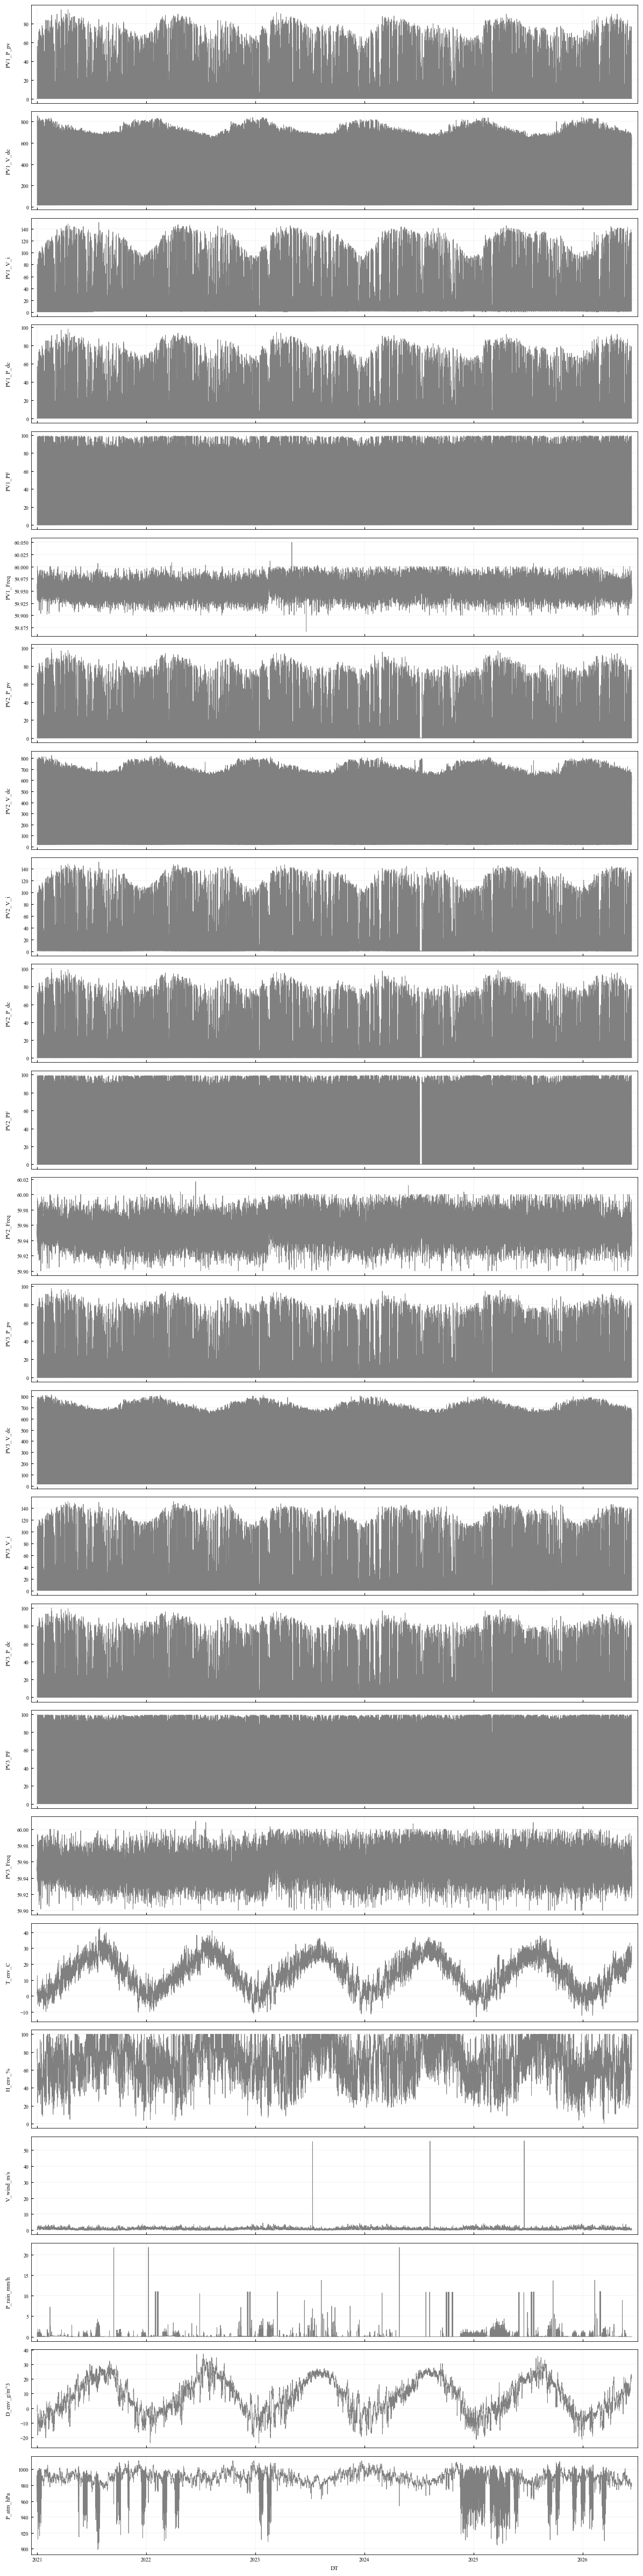

(<Figure size 1200x4800 with 24 Axes>,
 array([<Axes: ylabel='PV1_P_pv'>, <Axes: ylabel='PV1_V_dc'>,
        <Axes: ylabel='PV1_V_i'>, <Axes: ylabel='PV1_P_dc'>,
        <Axes: ylabel='PV1_PF'>, <Axes: ylabel='PV1_Freq'>,
        <Axes: ylabel='PV2_P_pv'>, <Axes: ylabel='PV2_V_dc'>,
        <Axes: ylabel='PV2_V_i'>, <Axes: ylabel='PV2_P_dc'>,
        <Axes: ylabel='PV2_PF'>, <Axes: ylabel='PV2_Freq'>,
        <Axes: ylabel='PV3_P_pv'>, <Axes: ylabel='PV3_V_dc'>,
        <Axes: ylabel='PV3_V_i'>, <Axes: ylabel='PV3_P_dc'>,
        <Axes: ylabel='PV3_PF'>, <Axes: ylabel='PV3_Freq'>,
        <Axes: ylabel='T_env_C'>, <Axes: ylabel='H_env_%'>,
        <Axes: ylabel='V_wind_m/s'>, <Axes: ylabel='P_rain_mm/h'>,
        <Axes: ylabel='D_env_g/m^3'>,
        <Axes: xlabel='DT', ylabel='P_atm_hPa'>], dtype=object))

In [91]:
importlib.reload(Library.dataProcessing)
from Library.dataProcessing import plot_selected_columns
plot_selected_columns(Site_02_filled, selected_columns, x='DT')

In [92]:
Site_02_filled.isna().sum()

timestamp      0
PV1_P_pv       0
PV1_V_dc       0
PV1_V_i        0
PV1_P_dc       0
PV1_PF         0
PV1_Freq       0
PV2_P_pv       0
PV2_V_dc       0
PV2_V_i        0
PV2_P_dc       0
PV2_PF         0
PV2_Freq       0
PV3_P_pv       0
PV3_V_dc       0
PV3_V_i        0
PV3_P_dc       0
PV3_PF         0
PV3_Freq       0
T_env_C        0
H_env_%        0
V_wind_m/s     0
P_rain_mm/h    0
D_env_g/m^3    0
P_atm_hPa      0
dtype: int64

In [93]:
Site_02_filled.to_csv(f"{preDataDirectory}Site#02_Data.gzip", index=False, compression="gzip")
Site_02_filled.to_csv(f"{dataDirectory}Site#02_Data.gzip", index=False, compression="gzip")

print('=' * 40)
print("Site#02 combined data saved")
print('-'*40)
print(f'In  "{preDataDirectory}Site#02_Data.gzip"')
print(f'and "{dataDirectory}Site#02_Data.gzip"')
print('=' * 40)

Site#02 combined data saved
----------------------------------------
In  "../../Database/2026-06-14/Preprocessed/Site#02_Data.gzip"
and "../Export/Data/Site#02_Data.gzip"
